In [1]:
import fair
fair.__version__

c:\Users\SetuPelz\Documents\GitHub\2023_carbondebt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'2.2.0'

In [2]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import os
import logging

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties

# Moving up one level as the ipynb is in the Code folder
os.chdir('..')

# turn off logging messages
logger = logging.getLogger('fair')
logger.setLevel(level=logging.CRITICAL)

In [3]:
# Thornhill is better for this calibration
f = FAIR(ch4_method="thornhill2021")
f.define_time(1750, 2100, 1)

In [4]:
# Load historical emissions (1750-2014)
emiss_hist = pd.read_csv("Data/fairparams/all_scaled_1750-2022.csv")

# Drop columns labelled from the years 2015 to 2022
years_to_drop = [str(year) for year in range(2015, 2023)]
emiss_hist = emiss_hist.drop(columns=years_to_drop, errors='ignore')

# Only keep the column 'variable' and the columns labelled from the years 1750 to 2014
years_to_keep = [str(year) for year in range(1750, 2015)]
emiss_hist = emiss_hist[['variable'] + years_to_keep]

# Set column names to sentence case
emiss_hist.columns = emiss_hist.columns.str.capitalize()

# Read in scenario data
emiss_scen = pd.read_csv("Data/pathways/ar6_impren/emiss_ar6_impren.csv")

# Drop 'AR6 climate diagnostics|Infilled|' strong prefix in 'Variable' column
emiss_scen['Variable'] = emiss_scen['Variable'].str.replace('AR6 climate diagnostics|Infilled|', '')

# Drop columns labelled from the years 1995 to 2014
years_to_drop = [str(year) for year in range(1995, 2015)]
emiss_scen = emiss_scen.drop(columns=years_to_drop, errors='ignore')

# Mapping dictionary to merge historical and scenario emissions
mapping_dict = {
    'Emissions|BC': 'Emissions|BC',
    'Emissions|CH4': 'Emissions|CH4',
    'Emissions|CO': 'Emissions|CO',
    'Emissions|CO2': None, 
    'Emissions|CO2|AFOLU': 'Emissions|CO2|AFOLU',
    'Emissions|CO2|Energy and Industrial Processes': 'Emissions|CO2|Energy and Industrial Processes',
    'Emissions|F-Gases': None,
    'Emissions|HFC': None, 
    'Emissions|HFC|HFC125': 'Emissions|HFC-125',
    'Emissions|HFC|HFC134a': 'Emissions|HFC-134a',
    'Emissions|HFC|HFC143a': 'Emissions|HFC-143a',
    'Emissions|HFC|HFC152a': 'Emissions|HFC-152a',
    'Emissions|HFC|HFC227ea': 'Emissions|HFC-227ea',
    'Emissions|HFC|HFC23': 'Emissions|HFC-23',
    'Emissions|HFC|HFC236fa': 'Emissions|HFC-236fa',
    'Emissions|HFC|HFC245ca': None,
    'Emissions|HFC|HFC32': 'Emissions|HFC-32',
    'Emissions|HFC|HFC365mfc': 'Emissions|HFC-365mfc',
    'Emissions|HFC|HFC43-10': 'Emissions|HFC-4310mee',
    'Emissions|Kyoto Gases (AR6-GWP100)': None,
    'Emissions|N2O': 'Emissions|N2O',
    'Emissions|NF3': 'Emissions|NF3',
    'Emissions|NH3': 'Emissions|NH3',
    'Emissions|NOx': 'Emissions|NOx',
    'Emissions|OC': 'Emissions|OC',
    'Emissions|PFC|C2F6': 'Emissions|C2F6',
    'Emissions|PFC|C3F8': 'Emissions|C3F8',
    'Emissions|PFC|C4F10': 'Emissions|C4F10',
    'Emissions|PFC|C5F12': 'Emissions|C5F12',
    'Emissions|PFC|C6F14': 'Emissions|C6F14',
    'Emissions|PFC|C7F16': 'Emissions|C7F16',
    'Emissions|PFC|C8F18': 'Emissions|C8F18',
    'Emissions|PFC|CF4': 'Emissions|CF4',
    'Emissions|PFC|cC4F8': 'Emissions|c-C4F8',
    'Emissions|SF6': 'Emissions|SF6',
    'Emissions|Sulfur': 'Emissions|Sulfur',
    'Emissions|SO2F2': 'Emissions|SO2F2',
    'Emissions|VOC': 'Emissions|VOC',
    'Emissions|CCl4': 'Emissions|CCl4',
    'Emissions|CFC11': 'Emissions|CFC-11',
    'Emissions|CFC113': 'Emissions|CFC-113',
    'Emissions|CFC114': 'Emissions|CFC-114',
    'Emissions|CFC115': 'Emissions|CFC-115',
    'Emissions|CFC12': 'Emissions|CFC-12',
    'Emissions|CH2Cl2': 'Emissions|CH2Cl2',
    'Emissions|CH3Br': 'Emissions|CH3Br',
    'Emissions|CH3CCl3': 'Emissions|CH3CCl3',
    'Emissions|CH3Cl': 'Emissions|CH3Cl',
    'Emissions|CHCl3': 'Emissions|CHCl3',
    'Emissions|HCFC141b': 'Emissions|HCFC-141b',
    'Emissions|HCFC142b': 'Emissions|HCFC-142b',
    'Emissions|HCFC22': 'Emissions|HCFC-22',
    'Emissions|Halon1202': None, 
    'Emissions|Halon1211': 'Emissions|Halon-1211',
    'Emissions|Halon1301': 'Emissions|Halon-1301',
    'Emissions|Halon2402': 'Emissions|Halon-2402',
}

# Rename emiss_scen rows in 'Variable' column to match the historical dataset
emiss_scen['Variable'] = emiss_scen['Variable'].replace(mapping_dict)

# Remove rows where 'Variable' did not match
emiss_scen = emiss_scen.dropna(subset=['Variable'])

# Combine historical and future emissions with a left join, common index is Variable
emiss = pd.merge(emiss_scen, emiss_hist, on="Variable", how="left")

# Drop rows where data is missing in historical or future
emiss = emiss.dropna()

# Mapping dictionary to prepare species names to match FaIR config file
mapping_dict_fair = {
    'Emissions|CO2|Energy and Industrial Processes': 'CO2 FFI',
    'Emissions|CO2|AFOLU': 'CO2 AFOLU',
    'Emissions|CO2': 'CO2',  
    'Emissions|CH4': 'CH4',
    'Emissions|N2O': 'N2O',
    'Emissions|Sulfur': 'Sulfur',
    'Emissions|BC': 'BC',
    'Emissions|OC': 'OC',
    'Emissions|NH3': 'NH3',
    'Emissions|NOx': 'NOx',
    'Emissions|VOC': 'VOC',
    'Emissions|CO': 'CO',
    'Emissions|CFC-11': 'CFC-11',  
    'Emissions|CFC-12': 'CFC-12',  
    'Emissions|CFC-113': 'CFC-113',  
    'Emissions|CFC-114': 'CFC-114',  
    'Emissions|CFC-115': 'CFC-115',  
    'Emissions|HCFC-22': 'HCFC-22',  
    'Emissions|HCFC-141b': 'HCFC-141b',  
    'Emissions|HCFC-142b': 'HCFC-142b',  
    'Emissions|CCl4': 'CCl4',  
    'Emissions|CHCl3': 'CHCl3',  
    'Emissions|CH2Cl2': 'CH2Cl2',  
    'Emissions|CH3Cl': 'CH3Cl',  
    'Emissions|CH3CCl3': 'CH3CCl3',  
    'Emissions|CH3Br': 'CH3Br',  
    'Emissions|Halon-1211': 'Halon-1211',  
    'Emissions|Halon-1301': 'Halon-1301',  
    'Emissions|Halon-2402': 'Halon-2402',  
    'Emissions|CF4': 'CF4',
    'Emissions|C2F6': 'C2F6',
    'Emissions|C3F8': 'C3F8',  
    'Emissions|c-C4F8': 'c-C4F8',  
    'Emissions|C4F10': 'C4F10',  
    'Emissions|C5F12': 'C5F12',  
    'Emissions|C6F14': 'C6F14',
    'Emissions|C7F16': 'C7F16',  
    'Emissions|C8F18': 'C8F18',  
    'Emissions|NF3': 'NF3',  
    'Emissions|SF6': 'SF6',
    'Emissions|SO2F2': 'SO2F2',  
    'Emissions|HFC-125': 'HFC-125',
    'Emissions|HFC-134a': 'HFC-134a',
    'Emissions|HFC-143a': 'HFC-143a',
    'Emissions|HFC-152a': 'HFC-152a',  
    'Emissions|HFC-227ea': 'HFC-227ea',
    'Emissions|HFC-23': 'HFC-23',
    'Emissions|HFC-236fa': 'HFC-236fa',  
    'Emissions|HFC-245fa': 'HFC-245fa',
    'Emissions|HFC-32': 'HFC-32',
    'Emissions|HFC-365mfc': 'HFC-365mfc',  
    'Emissions|HFC-4310mee': 'HFC-4310mee'
}

# Rename emiss_scen rows in 'Variable' column to match the historical dataset
emiss['Variable'] = emiss['Variable'].replace(mapping_dict_fair)

# Re arrange columns so that the columns from 2015 to 2100 are at the end, and 1750-2014 after 'Unit'
emiss = emiss[['Model', 'Scenario', 'Region', 'Variable', 'Unit'] + list(emiss.columns[91:]) + list(emiss.columns[5:91])]

# Write to csv
emiss.to_csv("Data/pathways/ar6_impren/emiss_ar6_impren_hist.csv", index=False)

In [5]:
emiss

,Model,Scenario,Region,Variable,Unit,1750,1751,1752,1753,1754,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
0,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,BC,Mt BC/yr,2.096766,2.071972,2.067178,2.070382,2.098586,...,2.749370,2.745640,2.741910,2.738180,2.734450,2.730720,2.726990,2.723260,2.719530,2.715800
1,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,CCl4,kt CCl4/yr,0.021567,0.021567,0.021567,0.021567,0.021567,...,0.437632,0.416363,0.395037,0.373768,0.352500,0.331232,0.309905,0.288637,0.267368,0.246100
2,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,CFC-11,kt CFC11/yr,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.647723,1.587646,1.527404,1.467327,1.407250,1.347173,1.286931,1.226854,1.166777,1.106700
3,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,CFC-113,kt CFC113/yr,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,CFC-114,kt CFC114/yr,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000202,0.000179,0.000157,0.000134,0.000112,0.000090,0.000067,0.000045,0.000022,0.000000
5,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,CFC-115,kt CFC115/yr,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.097058,0.093894,0.090723,0.087560,0.084396,0.081233,0.078061,0.074898,0.071735,0.068572
6,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,CFC-12,kt CFC12/yr,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.001199,0.002399,0.003601,0.004801,0.006000,0.007199,0.008402,0.009601,0.010801,0.012000
7,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,CH2Cl2,kt CH2Cl2/yr,207.491230,207.492121,207.492951,207.493780,207.494609,...,340.325458,340.238216,340.150734,340.063492,339.976250,339.889008,339.801527,339.714284,339.627042,339.539800
8,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,CH3Br,kt CH3Br/yr,106.689172,106.689172,106.689172,106.689172,106.689172,...,105.555018,105.522635,105.490165,105.457782,105.425400,105.393018,105.360547,105.328165,105.295782,105.263400
9,REMIND-MAgPIE 2.1-4.3,DeepElec_SSP2_ HighRE_Budg900,World,CH3CCl3,kt CH3CCl3/yr,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [6]:
# Determine scenarios 
scenarios = emiss.Scenario.unique().tolist()

# Set scenarios
f.define_scenarios(scenarios)

In [7]:
# Load config parameters
fair_params_1_4_1_file = 'data/fairparams/calibrated_constrained_parameters_calibration1.4.1.csv'
df_configs = pd.read_csv(fair_params_1_4_1_file, index_col=0)
configs = df_configs.index  # this is used as a label for the "config" axis
f.define_configs(configs)

In [8]:
# Load full species configuration file
species_config = pd.read_csv('data/fairparams/species_configs_properties_calibration1.4.1.csv')

# List of species that are always considered
always_considered = [
    'CO2', 'Solar', 'Volcanic', 'Aerosol-radiation interactions', 'Aerosol-cloud interactions',
    'Ozone', 'Light absorbing particles on snow and ice', 'Stratospheric water vapour',
    'Land use', 'Equivalent effective stratospheric chlorine', # 'Montreal gases' (removed here as we have them as separate species)
]

# Run species_config to only include those in 'emiss' DataFrame or the always considered species
species_config_run = species_config.loc[
    species_config['name'].isin(emiss['Variable'].unique()) | species_config['name'].isin(always_considered)
]

# Save the run to a new CSV file
species_config_run.to_csv('data/fairparams/species_configs_properties_calibration1.4.1_run.csv', index=False)

# Load the run species configuration and provide it to the FAIR object
fair_species_configs_1_4_1_file = 'data/fairparams/species_configs_properties_calibration1.4.1_run.csv'
species, properties = read_properties(filename=fair_species_configs_1_4_1_file)

# Define species in the FAIR model
f.define_species(species, properties)

In [9]:
# Set up all of the xarrays we need
f.allocate()

In [10]:
# Set up EESC for run
eesc = pd.read_csv('data/fairparams/eesc.csv')
eesc = pd.concat([eesc]*len(scenarios), ignore_index=True)
eesc['Scenario'] = np.repeat(scenarios, len(eesc) // len(scenarios))
eesc = eesc[['Scenario'] + list(eesc.columns[:-1])]
eesc.to_csv('data/fairparams/eesc_run.csv', index=False)

# Set up volcanic, solar and montreal forcing for desired scenarios (there are three rows for each scenario)
volcanic_solar = pd.read_csv('data/fairparams/volcanic_solar.csv')
volcanic_solar = pd.concat([volcanic_solar]*len(scenarios), ignore_index=True)
volcanic_solar['Scenario'] = np.repeat(scenarios, len(volcanic_solar) // len(scenarios))
volcanic_solar = volcanic_solar[['Scenario'] + list(volcanic_solar.columns[:-1])]
# Remove Montreal gasses from forcing as they are included in the species
volcanic_solar = volcanic_solar[volcanic_solar['Variable'] != 'Montreal gases']
volcanic_solar.to_csv('data/fairparams/volcanic_solar_run.csv', index=False)

In [11]:
# Add in emissions and forcing data
f.fill_from_csv(
    emissions_file='Data/pathways/ar6_impren/emiss_ar6_impren_hist.csv',
    concentration_file='Data/fairparams/eesc_run.csv', 
    forcing_file='Data/fairparams/volcanic_solar_run.csv', 
)

# Ensure that the solar and volcanic scale factors are picked up (always run)
fill(
    f.forcing,
    f.forcing.sel(specie="Volcanic") * df_configs["forcing_scale[Volcanic]"].values.squeeze(),
    specie="Volcanic",
)
fill(
    f.forcing,
    f.forcing.sel(specie="Solar") * df_configs["forcing_scale[Solar]"].values.squeeze(),
    specie="Solar",
)

In [12]:
# Add in parameters
f.fill_species_configs('Data/fairparams/species_configs_properties_calibration1.4.1_run.csv')
f.override_defaults('Data/fairparams/calibrated_constrained_parameters_calibration1.4.1.csv')

In [13]:
f.species_configs['forcing_reference_concentration'].sel(config=f.configs[0])

<xarray.DataArray 'forcing_reference_concentration' (specie: 60)> Size: 480B
array([       nan,        nan, 2.7715e+02, 7.3141e+02, 2.7387e+02,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       2.5000e-02, 4.8000e+00, 6.9100e+00, 4.5700e+02, 0.0000e+00,
       5.3000e+00, 4.4500e-03, 0.0000e+00, 0.0000e+00, 3.4050e+01,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan, 0.0000e+00])
Coordinates:
    config   int64 8B 1234
  * specie   (specie) <U43 10kB 'CO2 FFI' ... 'Equivalent effective stratosph...

In [14]:
# Initialise the run
initialise(f.concentration, f.species_configs["baseline_concentration"])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)
initialise(f.ocean_heat_content_change, 0)

In [15]:
# Run fair
f.run()

Running 841 projections in parallel: 100%|██████████| 350/350 [00:08<00:00, 42.72timesteps/s]


In [16]:
f.ghg_method

'meinshausen2020'

In [17]:
f.emissions.sel(scenario=f.scenarios[0], config=f.configs[0], timepoints=1751.5)

<xarray.DataArray (specie: 60)> Size: 480B
array([9.45634805e-03, 4.39686954e-02, 5.34250434e-02, 3.80885690e+01,
       9.88471297e-01, 2.26009358e+00, 2.06957494e+00, 1.51249201e+01,
       6.57141119e+00, 1.92251582e+01, 5.95291641e+01, 3.43138456e+02,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       2.15667760e-02, 2.04423734e+02, 2.07492536e+02, 4.40759845e+03,
       0.00000000e+00, 1.06689172e+02, 8.27590800e-03, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.06000000e-05, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan])
Coordinates:
    timepoints  float64 8B 1.752e+03
    scenario    <U29 116B 'DeepElec_SSP2_ HighRE_Budg900'
    config      int64 8B 1234
  * specie      (specie) <U43 10kB 'CO2 FFI' ... 'Equivalent effective strato...

In [18]:
f.species_configs['forcing_reference_concentration'].sel(config=f.configs[0])

<xarray.DataArray 'forcing_reference_concentration' (specie: 60)> Size: 480B
array([       nan,        nan, 2.7715e+02, 7.3141e+02, 2.7387e+02,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       2.5000e-02, 4.8000e+00, 6.9100e+00, 4.5700e+02, 0.0000e+00,
       5.3000e+00, 4.4500e-03, 0.0000e+00, 0.0000e+00, 3.4050e+01,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan, 0.0000e+00])
Coordinates:
    config   int64 8B 1234
  * specie   (specie) <U43 10kB 'CO2 FFI' ... 'Equivalent effective stratosph...

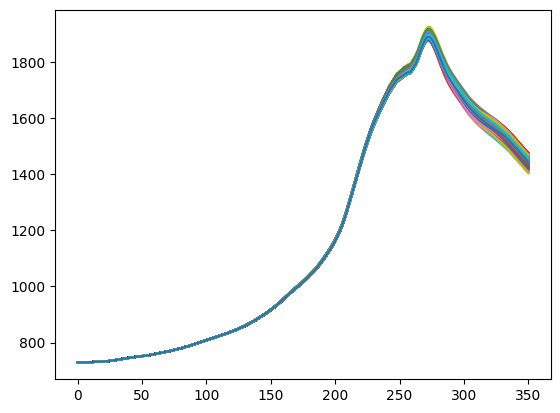

In [19]:
for scenario in f.scenarios:
    pl.plot(f.concentration.sel(specie='CH4', scenario=scenario))

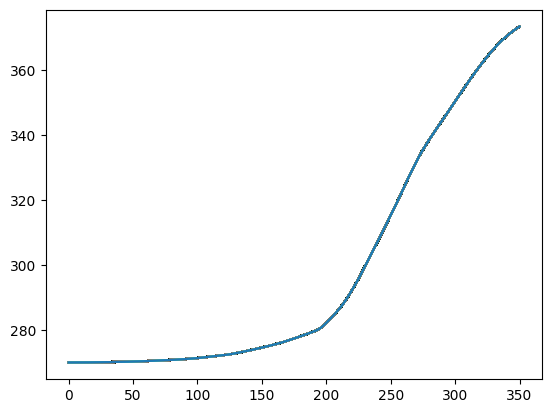

In [20]:
for scenario in f.scenarios:
    pl.plot(f.concentration.sel(specie='N2O', scenario=scenario))

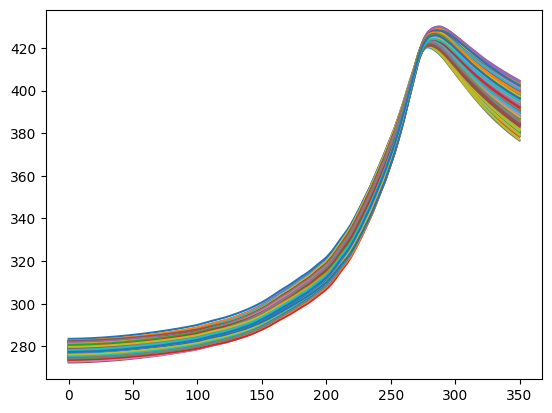

In [21]:
for scenario in f.scenarios:
    pl.plot(f.concentration.sel(specie='CO2', scenario=scenario))

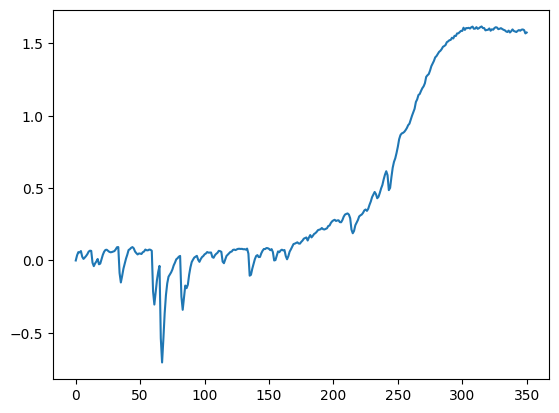

In [22]:
for scenario in f.scenarios:
    pl.plot(f.temperature.sel(scenario=scenario, layer=0).median(dim='config'))

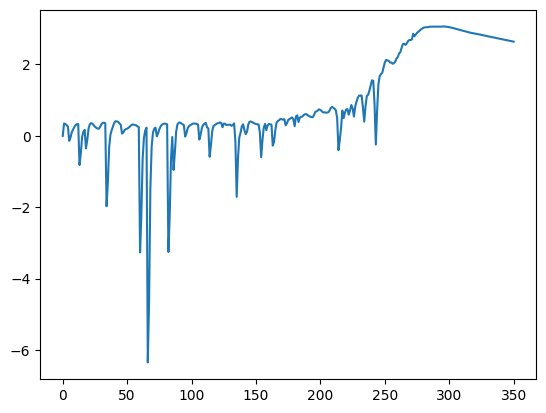

In [23]:
for scenario in f.scenarios:
    pl.plot(f.forcing_sum.sel(scenario=scenario).median(dim='config'))

In [24]:
for specie in f.species:
    print(specie, f.forcing.sel(scenario=f.scenarios[0], specie=specie, timebounds=2020).median(dim='config').values)

CO2 FFI nan
CO2 AFOLU nan
CO2 2.173025197475749
CH4 0.5602194609577368
N2O 0.2096284242330228
Sulfur nan
BC nan
OC nan
NH3 nan
NOx nan
VOC nan
CO nan
CFC-11 0.06412574397924865
CFC-12 0.17786524502226986
CFC-113 0.020721162286344845
CFC-114 0.005067862959043931
CFC-115 0.0021382634876978717
HCFC-22 0.05217497097713317
HCFC-141b 0.004168143978401202
HCFC-142b 0.004280686192683798
CCl4 0.013012581595586378
CHCl3 0.00051511806538897
CH2Cl2 0.0012020583767236692
CH3Cl 0.0005315797101195029
CH3CCl3 7.82308546884552e-05
CH3Br 6.7708500768044005e-06
Halon-1211 0.0009352911236511263
Halon-1301 0.000995714600508132
Halon-2402 0.00012033633627012213
CF4 0.0053002121338377225
C2F6 0.0013279562132275159
C3F8 0.0001944106157515417
c-C4F8 0.0005772120548138346
C4F10 7.73295650040806e-05
C5F12 6.183304590800512e-05
C6F14 0.00011176270362905276
C7F16 5.057950293347061e-05
C8F18 3.7783816720461986e-05
NF3 0.0004487936166035096
SF6 0.00563635509456839
SO2F2 0.0005354951447874572
HFC-125 0.00853040935565

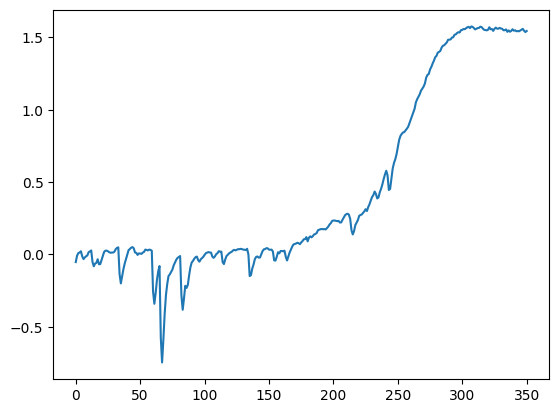

In [25]:
for scenario in f.scenarios:
    pl.plot(
        (
            f.temperature.sel(scenario=scenario, layer=0) -
            f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850,1901)).mean(dim='timebounds')
        ).median(dim='config')
    )

In [26]:
# Determine temperature response quantiles relative to 1850-1901

# Set quantiles
quantiles = [0.1, 0.167, 0.2, 0.3, 0.33, 0.4, 0.5, 0.6, 0.66, 0.7, 0.8, 0.833, 0.9]

# Extract temperature response
temperature_response = {}
for scenario in f.scenarios:
    temperature_response[scenario] = (
        f.temperature.sel(scenario=scenario, layer=0) -
        f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850,1901)).mean(dim='timebounds')
    ).quantile(quantiles, dim='config').rename('Temperature response')

# Convert to IAMC format
temperature_response_df = pd.concat(
    [temperature_response[scenario].to_dataframe().unstack() for scenario in f.scenarios],
    keys=f.scenarios,
    names=['Scenario']
).reset_index().rename(columns={'level_1': 'Quantile'})
temperature_response_df.columns = ['Scenario', 'Quantile'] + [f'{year:.0f}' for year in f.temperature.timebounds.values]

# Save as CSV
temperature_response_df.to_csv('Data/pathways/ar6_impren/emiss_ar6_impren_temps.csv', index=False)

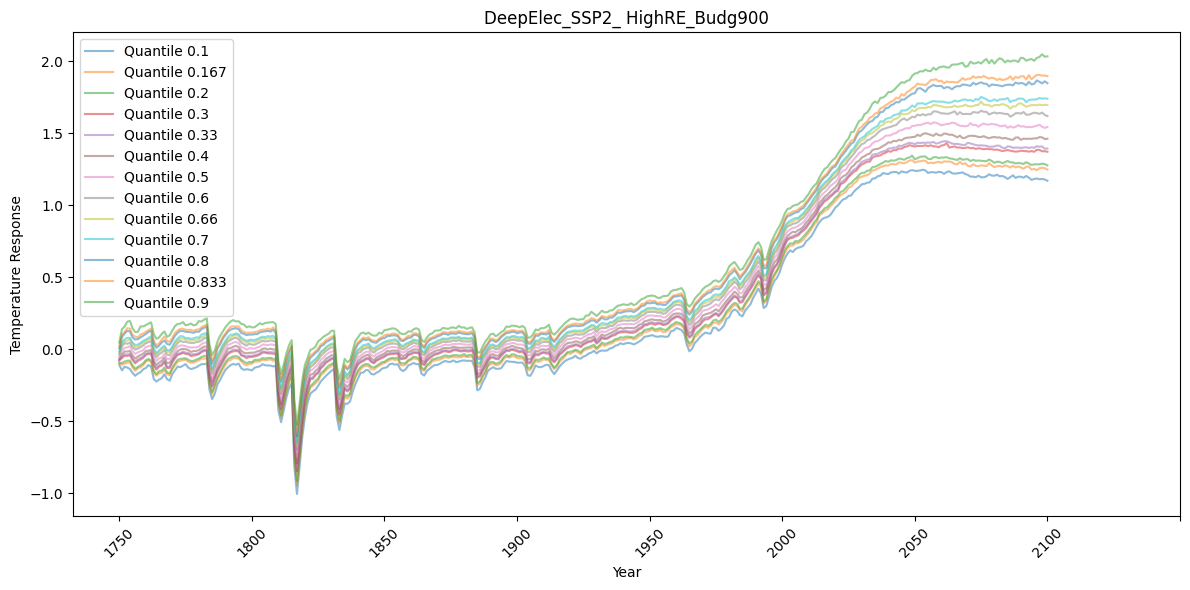

In [27]:
# Visualise temperature response quantiles 
fig, axes = pl.subplots(len(f.scenarios), 1, figsize=(12, 6 * len(f.scenarios)), sharex=True)

# Ensure axes is always iterable
if len(f.scenarios) == 1:
    axes = [axes]

for i, scenario in enumerate(f.scenarios):
    ax = axes[i]
    scenario_df = temperature_response_df[temperature_response_df['Scenario'] == scenario]
    for quantile in scenario_df['Quantile'].unique():
        quantile_df = scenario_df[scenario_df['Quantile'] == quantile]
        ax.plot(
            quantile_df.columns[2:], 
            quantile_df.iloc[0, 2:], 
            label=f'Quantile {quantile}',
            alpha=0.5,
        )
    ax.set_title(scenario)
    ax.set_ylabel('Temperature Response')
    ax.set_xticks(np.arange(0, 450, 50))  
    ax.tick_params(axis='x', rotation=45) 
    if i == len(f.scenarios) - 1:
        ax.set_xlabel('Year')

pl.tight_layout()
pl.legend()
pl.show()